# Übung 5

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### 5.1 Stichprobenkomplexität
In der Vorlesung haben Sie die Stichprobenkomplexität als Anzahl $N$ der Datenpunkte kennengelernt, die Sie mindestens benötigen, um mit einer Wahrscheinlichkeit von mindestens $(1-\delta)$ (mit $\delta > 0$) einen Generalisierungsfehler von höchstens $\epsilon$ zu erzielen. Grob vereinfacht: Die Stichprobenkomplexität beantwortet uns die Frage, wie viele Datenpunkte wir brauchen, damit der uns **unbekannte** Out-of-Sample Fehler $E_\text{out}$ nah am uns **bekannten** In-Sample Fehler $E_\text{in}$ liegt.

In der Vorlesung dieser Woche wurde eine Schranke für die Stichprobenkomplexität vorgestellt, die Sie nun untersuchen werden. Wir wollen einen Generalisierungsfehler von höchstens $\epsilon = 0.1$ erzielen, und zwar mit einer Wahrscheinlichkeit von mindestens $(1-\delta)$ mit $\delta=0.1$. Die Schranke für die Stichprobenkomplexität ist implizit in $N$, da $N$ auf beiden Seiten der Ungleichung auftaucht. Daher werden wir mit einer simplen iterativen Methode $N$ bestimmen.

**Ihre Aufgaben:**

(1) Schlagen Sie die Ungleichung für die Stichprobenkomplexität in der Vorlesung nach.

Okay

(2) Implementieren Sie eine Funktion, die für ein gegebenes $N, \delta, \epsilon, d_\text{VC}$ die Ungleichung auswertet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def stichprobenkomplexität(N, delta, eps, dvc):
    return (8/eps**2) * np.log((4*((2*N)**dvc) + 1) / delta)

(3) Nutzen Sie die Funktion aus (2), um folgendes iteratives Verfahren zu implementieren: Wenn für ein gegebenes $N$ die Ungleichung **nicht** erfüllt wird, dann nehmen Sie den Wert der rechten Seite der Ungleichung als neuen Wert für $N$. Iterieren Sie so lange, bis die Ungleichung erfüllt wird.

* Falls der Wert der rechten Seite der Ungleichung keine ganze Zahl ist, dann [runden Sie den Wert](https://docs.scipy.org/doc/numpy/reference/generated/numpy.ceil.html) zu einer ganzen Zahl auf. 

In [2]:
def calculate_n(N, delta, eps, dvc):
    while N < stichprobenkomplexität(N, delta, eps, dvc):
        N = np.ceil(stichprobenkomplexität(N, delta, eps, dvc))
    return N

(4) Nutzen Sie Ihr Verfahren aus (3), um die Stichprobenkomplexität (also $N$) für $d_\text{VC} \in \{3, 4, 5, 6\}$ zu bestimmen. Sie können als Startwert $N=1000$ wählen.

In [3]:
N = 1000
delta = 0.1
eps = 0.1
dvcs = [3, 4, 5, 6]
Ns = []
for dvc in dvcs:
    Ns.append(calculate_n(N, delta, eps, dvc))
print(Ns)

[29300.0, 38998.0, 48916.0, 59009.0]


(5) Erzeugen Sie einen Plot, der $N$ (y-Achse) gegen $d_\text{VC}$ (x-Achse) darstellt.

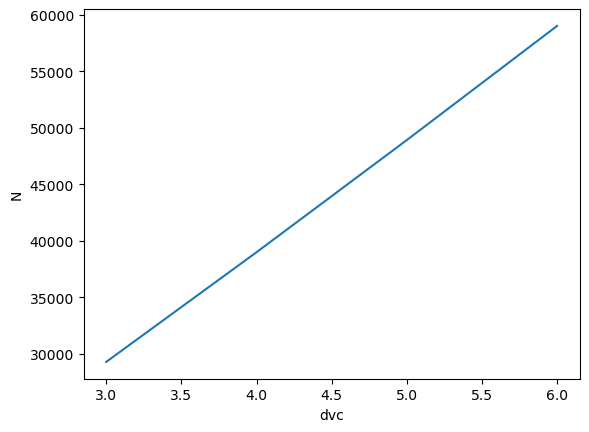

In [4]:
plt.plot(dvcs, Ns)
plt.xlabel("dvc")
plt.ylabel("N")
plt.show()

(6) Betrachten Sie Ihren Plot: Wie hängt $N$ von $d_\text{VC}$ ungefähr (ganz grob) ab? (1 Satz)

$N$ hängt linear von $d_\text{VC}$ ab.

(7) Vergleichen Sie Ihre Beobachtung aus (6) mit der Heuristik, die Sie in der Vorlesung zur Stichprobenkomplexität kennengelernt haben. Welchen Schluss ziehen Sie für die Stichprobenkomplexität, die wir aus der VC-Analyse gewonnen haben, in Bezug auf quantitative Aussagen? (1-3 Sätze)

Die Heuristik besagt, dass $N \geq 10 * d_\text{VC}$ zu wählen ist. Das entspricht grob den Werten, die mit der Stichprobenkomplexität berechnet wurden.

### 5.2 Verzerrung-Varianz Zerlegung
In der Vorlesung haben Sie die Verzerrung-Varianz Zerlegung (*bias variance decomposition*) kennengelernt. Wir haben dort den Fall behandelt, dass die Target Function und die Daten keine Rauschanteile besitzen. In der Realität sind fast alle Daten mit Rauschen kontaminiert. 

**Ihre Aufgaben**

(1) Schlagen Sie die Verzerrung-Varianz Zerlegung in den entsprechenden Folien nach.

Von mir aus

(2) Ersetzen Sie auf der entsprechenden Vorlesungsfolie $f(x)$ durch $f(x)' = f(x) + \epsilon$, wobei $\epsilon$ unser Rauschen modelliert. $\epsilon$ sei eine Zufallsvariable mit Erwartungswert $0$ und Varianz $\sigma^2$.

(3) Zeigen Sie, dass gilt:

$$\mathbb{E}_\mathcal{D} \left[E_\text{out}(g^{(\mathcal{D})})\right] = \sigma^2 + \text{bias} + \text{var}$$

Die Kontamination durch Rauschen erhöht also unseren Out-of-Sample Fehler.

### 5.3 Approximations-Generalisierungsabwägung

* Diese Übung werden Sie voraussichtlich zu Hause bearbeiten wollen.

Wie trifft man gute Entscheidungen? Und was hat das mit der Approximations-Generalisierungsabwägung zu tun?

> Die Approximations-Generalisierungsabwägung und die Bias-Variance-Decomposition (*Verzerrung-Varianz Zerlegung*) haben Sie im Rahmen der Vorlesung bereits kennengelernt. Sie werden diesen Konzepten in verschiedenen Kontexten auch außerhalb der Vorlesung immer wieder begegnen, wenn Sie sie erkennen. In dieser Übung möchte ich Sie dazu *einladen*, diese Konzepte in anderen Zusammenhängen wiederzufinden und damit besser erinnern zu können. Unser Gehirn arbeitet (soweit dies bekannt ist) wie ein assoziativer Speicher: Sie verfügen über vernetzte Assoziationen und Erinnerungen. Wenn es Ihnen gelingt, die Lerninhalte mit Ihrem vorhandenen Wissen zu vernetzen, dann festigen Sie den Lernstoff und er bleibt Ihnen leichter im Gedächtnis. Mit dieser Übung möchte ich Ihnen "Vernetzungsmaterial" für Ihren Lernprozess bereitstellen.

Herr Gerd Gigerenzer ist promovierter Psychologe und emeritierter Direktor des Max-Planck-Instituts für Bildungsforschung in Berlin. Er hat sich im Rahmen seiner Forschungstätigkeit lange damit auseinandergesetzt, wie Menschen Entscheidungen treffen. Ich habe Ihnen seinen Vortrag "**Einfache Regeln für komplexe Entscheidungen**" aus dem Jahr 2017 als YouTube Video verlinkt. Der Vortrag hat eine Länge von etwa einer Stunde.

1. Nehmen Sie sich die Folien der Vorlesung zur Hand, insbesondere diese, die die Approximations-Generalisierungsabwägung und die Verzerrung-Varianz Zerlegung behandeln.
2. Lesen Sie sich die untenstehenden Fragen durch.
3. Nehmen Sie sich Zeit und schauen den [hier](https://youtu.be/Iia0kTMZBGM) verlinkten Vortrag an. Alternativ können Sie [hier](https://data.bialonski.de/ml/gigerenzer-talk-2017.m4a) die Audiospur als Datei herunterladen und z.B. auf Ihrem Smartphone anhören. Achten Sie darauf, dass Sie Ihre Kolleginnen und Kollegen dabei nicht stören.
   * Wenn Sie gar keine Lust auf diese Übung verspüren sollten (was ich schade fände), dann lesen Sie immerhin den ROT13 kodierten Tipp. Ihnen entgehen viele Beispiele (und damit "Vernetzungsmaterial"), aber Sie werden dann immer noch einige Aussagen mitbekommen. ROT13: Fvr xöaara Vuer Orneorvghatfmrvg noxüemra, vaqrz Fvr fvpu no Zvahgr Ivrehaqivremvt qra Ibegent nafpunhra.
4. Beantworten Sie die untenstehenden Fragen.   

**Fragen**

(1) Gerd Gigerenzer benutzt etwas andere Begriffe als wir das in der Lehrveranstaltung getan haben. In der Vorlesung sprechen wir von *Target Function*, *Komplexität der Target Function*, *Hypothesenset (bzw. Modell)*, *Datensatzgröße N*. Welcher dieser Begriffe entspricht dem im Vortrag oft genutzten Begriff "Heuristik"? (1 Satz)

(2) In welchen Situationen liefern - laut Gigerenzer - einfache Heuristiken bessere Vorhersagen als komplexe Modelle? Welche Eigenschaften zeichnen solche Situationen aus? (1-5 Sätze oder Stichworte)

(3) Formulieren Sie die Aussagen aus (2) um mithilfe der Begriffe aus der Approximations-Generalisierungsabwägung (aus der VC-Analyse): Warum erwarten Sie unter welchen Umständen für einfache Heuristiken bessere Vorhersagen als für komplexe Modelle? (etwa 1-6 Sätze bzw. ein Absatz)

(4) Erwarten Sie für einfache Modelle einen hohen oder niedrigen Bias? Erwarten Sie eine hohe oder niedrige Varianz? (Stichworte)

(5) Erwarten Sie für komplexe Modelle einen hohen oder niedrigen Bias? Erwarten Sie eine hohe oder niedrige Varianz? (Stichworte)

(6) Optional (und nur meiner Neugier geschuldet). Sofern ein Beispiel aus Gigerenzers Vortrag Ihnen besonders in Erinnerung geblieben ist oder Ihnen besonders eingeleuchtet hat: Welches Beispiel war dies? (Stichworte)